# Scientific Image Forgery Dataset Explorer

Single notebook to:
- verify dataset folders are present
- measure storage consumption (counts + total bytes) for forged/authentic/mask/test splits
- preview any forged sample with its mask overlay

No extra statistics (like width/height) are computed—only size-related info plus a manual sample viewer. Run cells in order and tweak paths if your dataset lives elsewhere.


###Get dataset

In [ ]:
import google.colab.drive as mount
mount.google_drive()

In [ ]:
#upload your kaggle.json API key from kaggle.
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"dyslexiainthebrain","key":"c030414a58e2a0fb173c8e3b19d4394c"}'}

In [ ]:
!mkdir -p /root/.config/kaggle
!mv kaggle.json /root/.config/kaggle

In [ ]:
!kaggle competitions download -c recodai-luc-scientific-image-forgery-detection
!unzip /content/recodai-luc-scientific-image-forgery-detection.zip

###Install dependencies

In [ ]:
%pip install matplotlib
%pip install numpy
%pip install pandas
%pip install pillow

In [12]:
from pathlib import Path
from typing import Dict, List

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

%matplotlib inline


In [13]:
# Dataset configuration
DATASET_ROOT = Path("drive/MyDrive/Datasets/recodai-luc-scientific-image-forgery-detection").resolve()
FORGED_DIR = DATASET_ROOT / "train_images" / "forged"
AUTHENTIC_DIR = DATASET_ROOT / "train_images" / "authentic"
MASK_DIR = DATASET_ROOT / "train_masks"
TEST_DIR = DATASET_ROOT / "test_images"

print(f"Dataset root: {DATASET_ROOT}")


Dataset root: /content/drive/MyDrive/Datasets/recodai-luc-scientific-image-forgery-detection


In [14]:
required = {
    "Forged": FORGED_DIR,
    "Authentic": AUTHENTIC_DIR,
    "Masks": MASK_DIR,
    "Test images": TEST_DIR,
}

missing = [name for name, path in required.items() if not path.exists()]
if missing:
    raise FileNotFoundError(f"Missing folders: {missing}")

print("All required folders found ✔️")


All required folders found ✔️


## 1. Collect file counts

We only need aggregate counts for forged, authentic, mask, and test folders. The helper below walks each directory and records the number of files found.


In [15]:
def human_readable_size(num_bytes: int) -> str:
    if num_bytes == 0:
        return "0 B"
    units = ["B", "KB", "MB", "GB", "TB"]
    size = float(num_bytes)
    for unit in units:
        if size < 1024.0:
            return f"{size:.2f} {unit}"
        size /= 1024.0
    return f"{size:.2f} PB"

splits = [
    ("Forged images", FORGED_DIR, "*.png"),
    ("Authentic images", AUTHENTIC_DIR, "*.png"),
    ("Masks", MASK_DIR, "*.npy"),
    ("Test images", TEST_DIR, "*.png"),
]

summary_rows = []
collected_files: Dict[str, List[Path]] = {}

for name, folder, pattern in splits:
    files = sorted(folder.rglob(pattern))
    collected_files[name] = files
    total_bytes = sum(p.stat().st_size for p in files)
    summary_rows.append({
        "Split": name,
        "File count": len(files),
        "Total bytes": total_bytes,
        "Readable size": human_readable_size(total_bytes),
    })

summary_df = pd.DataFrame(summary_rows)
summary_df


,Split,File count,Total bytes,Readable size
0,Forged images,2751,2668564682,2.49 GB
1,Authentic images,2377,2425114247,2.26 GB
2,Masks,2751,3956952095,3.69 GB
3,Test images,1,265872,259.64 KB


In [16]:
total_bytes = summary_df["Total bytes"].sum()
print(f"Total storage across tracked splits: {human_readable_size(total_bytes)} ({total_bytes:,} bytes)")


Total storage across tracked splits: 8.43 GB (9,050,896,896 bytes)


## 2. Preview a forged sample

Set `sample_idx` in the next cell to choose which forged image to display. The notebook will overlay the corresponding mask if it exists.


Showing forged image #456: 19668.png
Mask path: /content/drive/MyDrive/Datasets/recodai-luc-scientific-image-forgery-detection/train_masks/19668.npy


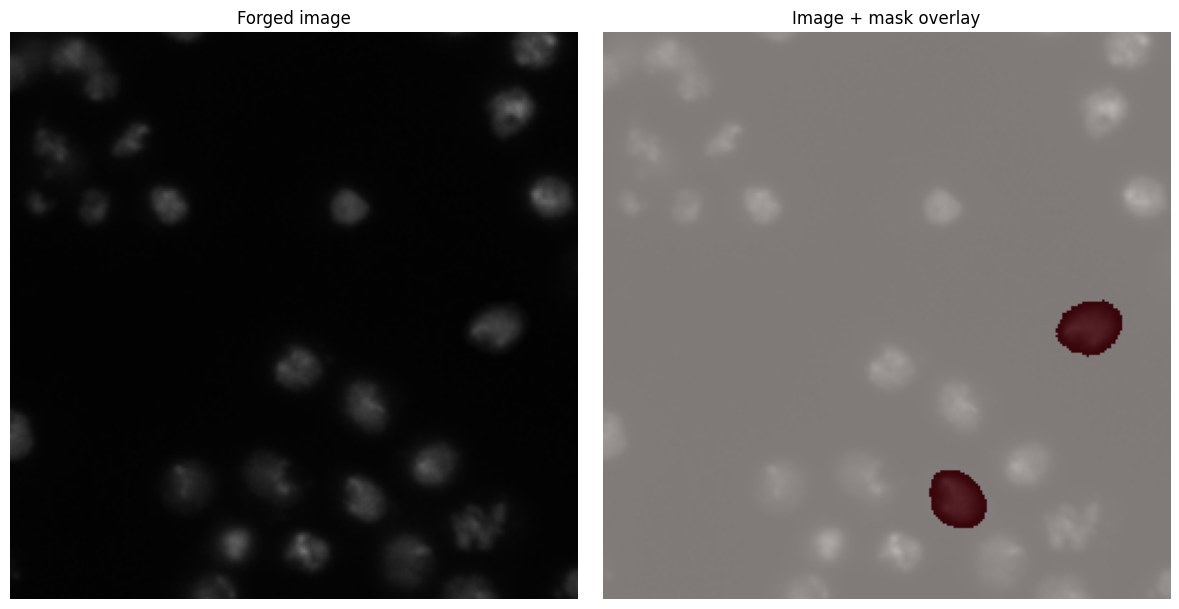

In [22]:
sample_idx = 456  # change this to inspect a different forged image
forged_files = collected_files.get("Forged images", [])

if not forged_files:
    raise ValueError("No forged images were indexed. Check dataset paths above.")

sample_idx = int(np.clip(sample_idx, 0, len(forged_files) - 1))
image_path = forged_files[sample_idx]
mask_path = MASK_DIR / f"{image_path.stem}.npy"

print(f"Showing forged image #{sample_idx}: {image_path.name}")
print(f"Mask path: {mask_path if mask_path.exists() else 'missing'}")

image_np = np.array(Image.open(image_path).convert("RGB"))
mask_np = None
if mask_path.exists():
    mask_np = np.load(mask_path)
    mask_np = np.squeeze(mask_np) # This will remove dimensions of size 1

    # If the mask is still 3D and has 2 channels, assume it's (channels, height, width)
    # and select the first channel to make it 2D for imshow.
    if mask_np.ndim == 3 and mask_np.shape[0] == 2:
        mask_np = mask_np[0, :, :]

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(image_np)
axes[0].set_title("Forged image")
axes[0].axis("off")

axes[1].imshow(image_np)
if mask_np is not None:
    axes[1].imshow(mask_np, alpha=0.5, cmap="Reds")
    axes[1].set_title("Image + mask overlay")
else:
    axes[1].set_title("Mask missing")
axes[1].axis("off")

plt.tight_layout()
plt.show()